# Similarity Analysis
The similarity matrix measures the textual overlap between all model outputs using TF-IDF and cosine similarity. Each cell represents how similar two models' outputs are, where 1.0 indicates identical text and 0.0 indicates no overlap. This reveals which models produce redundant outputs and how models cluster by output style.

In [1]:
import subprocess, sys, os, glob, csv
import numpy as np
import matplotlib.pyplot as plt

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# model outputs
try:
    from google.colab import files
    uploaded = files.upload()
    model_texts = {
        fname.replace("_output", "").replace(".md", ""): content.decode("utf-8", errors="replace")
        for fname, content in uploaded.items()
    }
except ImportError:
    folder = "data/models_outputs"
    model_texts = {
        os.path.basename(p).replace("_output", "").replace(".md", ""): open(p, encoding="utf-8").read()
        for p in glob.glob(os.path.join(folder, "*.md"))
    }

model_names = sorted(model_texts.keys())
print(f"{len(model_names)} models loaded: {model_names}")

Saving chandra_output.md to chandra_output.md
Saving deepseek_ocr_output.md to deepseek_ocr_output.md
Saving deepseek_ocr2_output.md to deepseek_ocr2_output.md
Saving docling_output.md to docling_output.md
Saving doctr_output.md to doctr_output.md
Saving easyocr_output.md to easyocr_output.md
Saving florence2_output.md to florence2_output.md
Saving gemini2.5_output.md to gemini2.5_output.md
Saving GLM_ocr_output.md to GLM_ocr_output.md
Saving haiku_output.md to haiku_output.md
Saving hunyuan_output.md to hunyuan_output.md
Saving landingai_output.md to landingai_output.md
Saving latex_output.md to latex_output.md
Saving lightonocr_output.md to lightonocr_output.md
Saving llamaindex.md to llamaindex.md
Saving llamaparse_output.md to llamaparse_output.md
Saving mistral_output.md to mistral_output.md
Saving nemotron_ocr_output.md to nemotron_ocr_output.md
Saving paddle_ocr_output.md to paddle_ocr_output.md
Saving pdfplumber_output.md to pdfplumber_output.md
Saving Qianfan_ocr_output.md to 

In [3]:
# TF-IDF similaritet
corpus = [model_texts[m] for m in model_names]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
S = cosine_similarity(X)

print("Similarity matrix computed:", S.shape)

Similarity matrix computed: (26, 26)


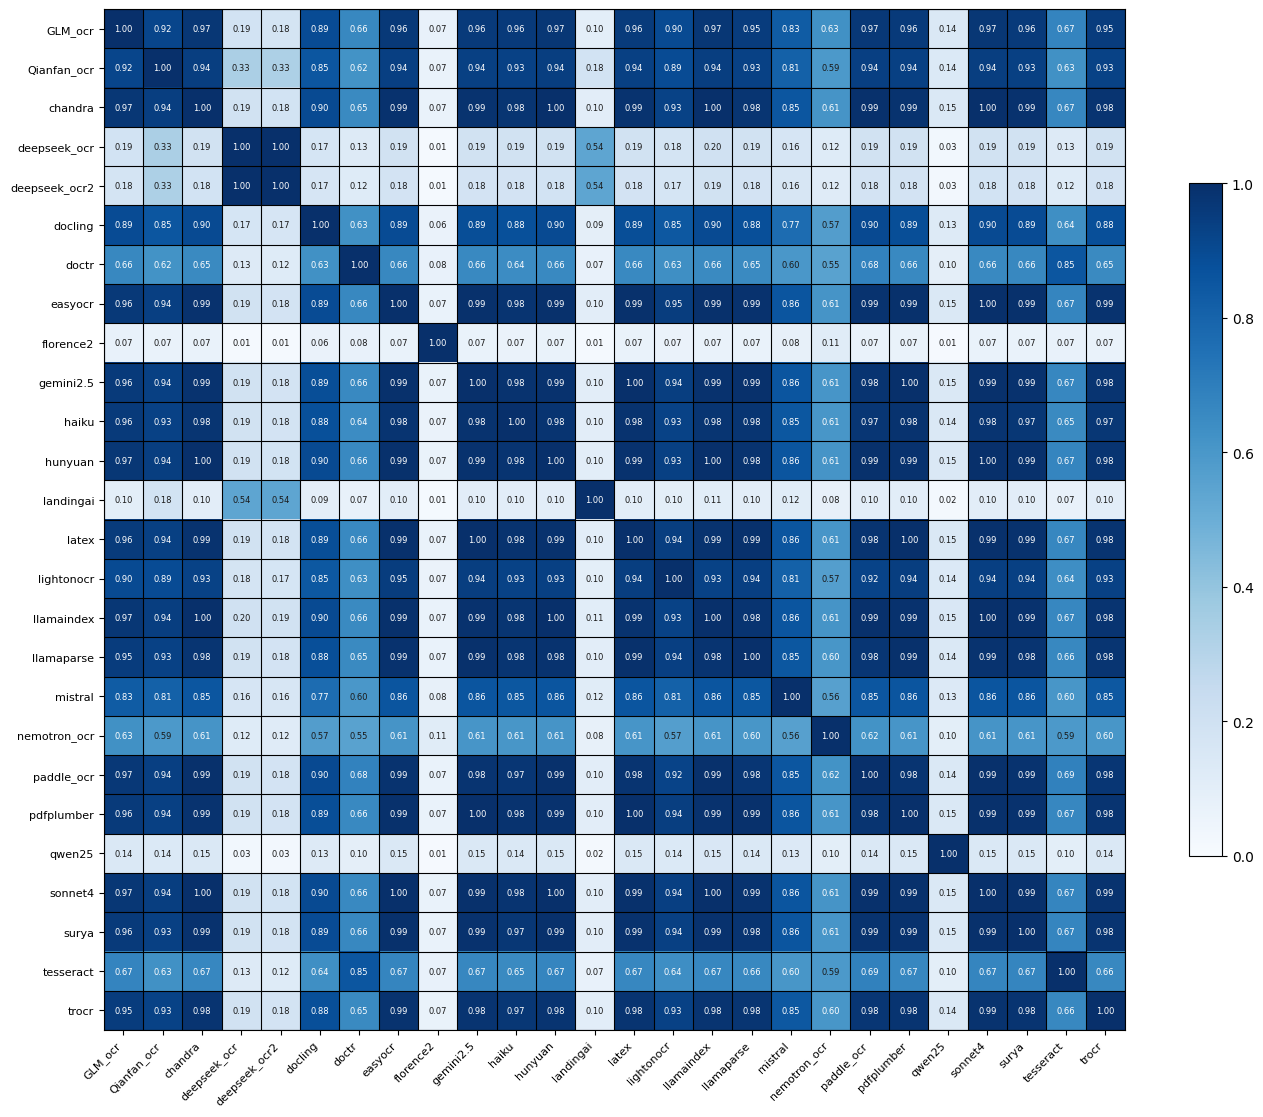

In [6]:
# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(S, cmap="Blues", vmin=0, vmax=1)

n = len(model_names)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(model_names, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(model_names, fontsize=8)

# Värdetext
for i in range(n):
    for j in range(n):
        val = S[i, j]
        color = "white" if val > 0.6 else "#1a1a1a"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=color)

# Tabelllinjer
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color="black", linewidth=0.8)
ax.tick_params(which="minor", length=0)

fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.savefig("similarity_heatmap_visual.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
#  Export CSV
with open("similarity_matrix.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["model"] + model_names)
    for i, name in enumerate(model_names):
        w.writerow([name] + list(np.round(S[i], 4)))
print("Saved: similarity_matrix.csv")

Saved: similarity_matrix.csv
